# _1 — Mapa interativo de notificações de dengue (BA, 2026)

Coropleta por município com base em `DENGBA26.csv` (local de notificação na Bahia).

Dados parciais: exportação SINAN até **21/06/2026**.

In [41]:
from __future__ import annotations

import json
from pathlib import Path

import folium
import pandas as pd
import requests
from branca.colormap import linear
from IPython.display import display

# --- parâmetros (altere aqui para outro ano/estado) -------------------------

ANO = 2024
UF = "ba"

# ---------------------------------------------------------------------------

_cwd = Path.cwd()
ROOT = _cwd.parent if (_cwd.parent / "data").exists() else _cwd

CSV = ROOT / "data" / "processed" / UF / "raw" / f"DENG{UF.upper()}{str(ANO)[-2:]}.csv"
GEO = ROOT / "data/raw/geo/ba_municipios.geojson"

print(f"CSV:  {CSV}")
print(f"Geo:  {GEO}")
print(f"Existe: {CSV.exists()}")

CSV:  /Users/antonielmagalhaes/d/acad/ia-final/ia-iv/data/processed/ba/raw/DENGBA24.csv
Geo:  /Users/antonielmagalhaes/d/acad/ia-final/ia-iv/data/raw/geo/ba_municipios.geojson
Existe: True


## 1. Agregar notificações por município

In [42]:
df = pd.read_csv(CSV, usecols=["ID_MUNICIP", "DT_NOTIFIC"], parse_dates=["DT_NOTIFIC"], low_memory=False)

counts = (
    df.groupby("ID_MUNICIP", as_index=False)
    .size()
    .rename(columns={"size": "notificacoes"})
    .sort_values("notificacoes", ascending=False)
)

print(f"Período: {df['DT_NOTIFIC'].min():%d/%m/%Y} — {df['DT_NOTIFIC'].max():%d/%m/%Y}")
print(f"Total: {len(df):,} notificações em {counts['ID_MUNICIP'].nunique()} municípios".replace(",", "."))
counts.head(10)

Período: 31/12/2023 — 28/12/2024
Total: 231.942 notificações em 415 municípios


,ID_MUNICIP,notificacoes
410,293330,36462
333,292740,11201
64,290520,9003
129,291080,8475
34,290290,8078
347,292870,5673
385,293135,4809
372,293050,4196
141,291170,4012
172,291460,3432


## 2. Enriquecer com GeoJSON e nomes (IBGE)

In [43]:
with GEO.open(encoding="utf-8") as f:
    geo = json.load(f)

# ID_MUNICIP (6 dígitos) ↔ codarea (7 dígitos no GeoJSON)
id_to_codarea: dict[int, str] = {}
for feat in geo["features"]:
    codarea = str(feat["properties"]["codarea"])
    id_to_codarea[int(codarea) // 10] = codarea

counts["codarea"] = counts["ID_MUNICIP"].map(id_to_codarea)

# Nomes via API IBGE (417 municípios da BA)
ibge = pd.DataFrame(requests.get(
    "https://servicodados.ibge.gov.br/api/v1/localidades/estados/29/municipios",
    timeout=30,
).json())
ibge = ibge.rename(columns={"id": "codarea", "nome": "municipio"})
ibge["codarea"] = ibge["codarea"].astype(str)

map_df = counts.merge(ibge, on="codarea", how="left")
map_df["municipio"] = map_df["municipio"].fillna(map_df["codarea"])
map_df.head()

,ID_MUNICIP,notificacoes,codarea,municipio,microrregiao,regiao-imediata
0,293330,36462,2933307,Vitória da Conquista,"{'id': 29028, 'nome': 'Vitória da Conquista', ...","{'id': 290011, 'nome': 'Vitória da Conquista',..."
1,292740,11201,2927408,Salvador,"{'id': 29021, 'nome': 'Salvador', 'mesorregiao...","{'id': 290001, 'nome': 'Salvador', 'regiao-int..."
2,290520,9003,2905206,Caetité,"{'id': 29026, 'nome': 'Guanambi', 'mesorregiao...","{'id': 290016, 'nome': 'Guanambi', 'regiao-int..."
3,291080,8475,2910800,Feira de Santana,"{'id': 29012, 'nome': 'Feira de Santana', 'mes...","{'id': 290029, 'nome': 'Feira de Santana', 're..."
4,290290,8078,2902906,Barra do Choça,"{'id': 29028, 'nome': 'Vitória da Conquista', ...","{'id': 290011, 'nome': 'Vitória da Conquista',..."


## 3. Mapa interativo (Folium)

Passe o mouse sobre o município para ver nome e total. Use zoom e arraste para explorar.

In [44]:
# Injeta contagem e nome em cada feature do GeoJSON
lookup = map_df.set_index("codarea")[["notificacoes", "municipio"]].to_dict("index")
for feat in geo["features"]:
    ca = str(feat["properties"]["codarea"])
    info = lookup.get(ca, {"notificacoes": 0, "municipio": ca})
    feat["properties"]["notificacoes"] = int(info["notificacoes"])
    feat["properties"]["municipio"] = info["municipio"]

m = folium.Map(location=[-12.5, -41.7], zoom_start=6, tiles="CartoDB positron")

colormap = linear.YlOrRd_09.scale(0, map_df["notificacoes"].max())
colormap.caption = "Notificações de dengue (2026, parcial)"

folium.GeoJson(
    geo,
    name="Notificações por município",
    style_function=lambda feat: {
        "fillColor": colormap(feat["properties"]["notificacoes"]),
        "color": "#555",
        "weight": 0.6,
        "fillOpacity": 0.75,
    },
    highlight_function=lambda feat: {"weight": 2, "color": "#111", "fillOpacity": 0.9},
    tooltip=folium.GeoJsonTooltip(
        fields=["municipio", "notificacoes"],
        aliases=["Município", "Notificações"],
        localize=True,
    ),
).add_to(m)

colormap.add_to(m)
folium.LayerControl().add_to(m)

display(m)

## 4. Top 15 municípios

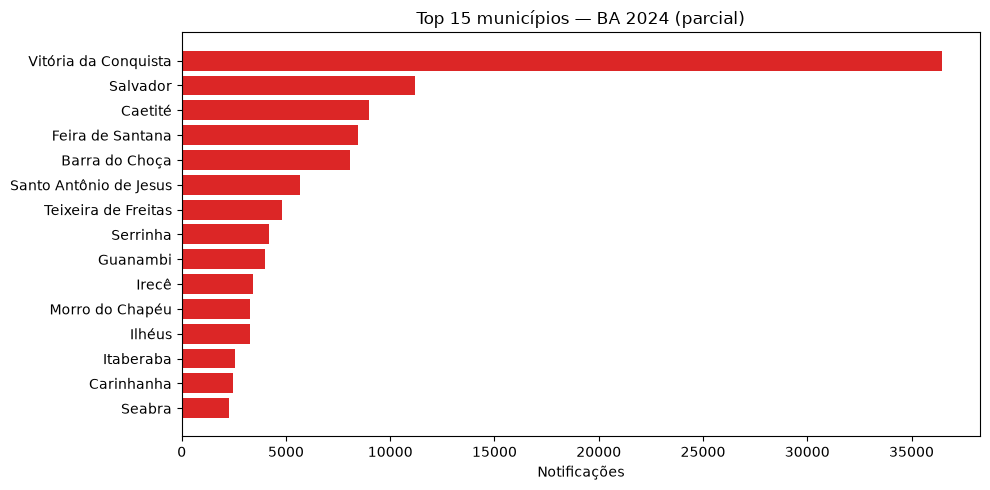

In [45]:
import matplotlib.pyplot as plt

top = map_df.nlargest(15, "notificacoes")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top["municipio"][::-1], top["notificacoes"][::-1], color="#dc2626")
ax.set_xlabel("Notificações")
ax.set_title(f"Top 15 municípios — BA {ANO} (parcial)")
plt.tight_layout()
plt.show()

## 5. Ano a ano (scroll)

Use o slider para percorrer **2016–2026**. O mapa e o resumo atualizam a cada ano.

In [46]:
import copy

import ipywidgets as widgets
from IPython.display import HTML, clear_output

with GEO.open(encoding="utf-8") as f:
    geo_template = json.load(f)

PROCESSED = ROOT / "data" / "processed" / UF / "raw"
ibge_nomes = ibge[["codarea", "municipio"]]


def load_year(ano: int) -> dict:
    path = PROCESSED / f"DENG{UF.upper()}{str(ano)[-2:]}.csv"
    if not path.exists():
        raise FileNotFoundError(path)

    df_y = pd.read_csv(
        path,
        usecols=["ID_MUNICIP", "DT_NOTIFIC"],
        parse_dates=["DT_NOTIFIC"],
        low_memory=False,
    )
    counts_y = (
        df_y.groupby("ID_MUNICIP", as_index=False)
        .size()
        .rename(columns={"size": "notificacoes"})
    )
    counts_y["codarea"] = counts_y["ID_MUNICIP"].map(id_to_codarea)
    map_y = counts_y.merge(ibge_nomes, on="codarea", how="left")
    map_y["municipio"] = map_y["municipio"].fillna(map_y["codarea"])

    return {
        "map_df": map_y,
        "periodo": f"{df_y['DT_NOTIFIC'].min():%d/%m/%Y} — {df_y['DT_NOTIFIC'].max():%d/%m/%Y}",
        "total": len(df_y),
        "municipios": counts_y["ID_MUNICIP"].nunique(),
    }


def build_map(ano: int, data: dict) -> folium.Map:
    map_df_y = data["map_df"]
    lookup_y = map_df_y.set_index("codarea")[["notificacoes", "municipio"]].to_dict("index")

    geo_y = copy.deepcopy(geo_template)
    for feat in geo_y["features"]:
        ca = str(feat["properties"]["codarea"])
        info = lookup_y.get(ca, {"notificacoes": 0, "municipio": ca})
        feat["properties"]["notificacoes"] = int(info["notificacoes"])
        feat["properties"]["municipio"] = info["municipio"]

    vmax = max(map_df_y["notificacoes"].max(), 1)
    m = folium.Map(location=[-12.5, -41.7], zoom_start=6, tiles="CartoDB positron")
    cmap = linear.YlOrRd_09.scale(0, vmax)
    cmap.caption = f"Notificações — BA {ano}"

    folium.GeoJson(
        geo_y,
        style_function=lambda feat, c=cmap: {
            "fillColor": c(feat["properties"]["notificacoes"]),
            "color": "#555",
            "weight": 0.6,
            "fillOpacity": 0.75,
        },
        highlight_function=lambda feat: {"weight": 2, "color": "#111", "fillOpacity": 0.9},
        tooltip=folium.GeoJsonTooltip(
            fields=["municipio", "notificacoes"],
            aliases=["Município", "Notificações"],
            localize=True,
        ),
    ).add_to(m)
    cmap.add_to(m)
    return m


print("Carregando anos disponíveis…")
anos = sorted(int(p.stem[-2:]) + 2000 for p in PROCESSED.glob(f"DENG{UF.upper()}*.csv"))
year_cache = {}
for ano in anos:
    year_cache[ano] = load_year(ano)
    d = year_cache[ano]
    print(
        f"  {ano}: {d['total']:,} notif. | {d['municipios']} mun. | {d['periodo']}".replace(",", ".")
    )

map_out = widgets.Output()
info = widgets.HTML()

slider = widgets.IntSlider(
    value=anos[-1],
    min=anos[0],
    max=anos[-1],
    step=1,
    description="Ano",
    continuous_update=False,
    readout_format="d",
    layout=widgets.Layout(width="500px"),
)


def render_year(ano: int) -> None:
    data = year_cache[ano]
    top3 = data["map_df"].nlargest(3, "notificacoes")
    top_txt = ", ".join(
        f"{row.municipio} ({row.notificacoes:,})".replace(",", ".")
        for row in top3.itertuples()
    )
    info.value = (
        f"<b>{ano}</b> — {data['periodo']}<br>"
        f"<b>{data['total']:,}</b> notificações em <b>{data['municipios']}</b> municípios<br>"
        f"Top 3: {top_txt}"
    )
    with map_out:
        clear_output(wait=True)
        display(build_map(ano, data))


def on_slider(change: dict) -> None:
    if change["name"] == "value" and change["type"] == "change":
        render_year(change["new"])


slider.observe(on_slider, names="value")
render_year(slider.value)

display(widgets.VBox([slider, info, map_out]))

Carregando anos disponíveis…
  2016: 83.363 notif. | 370 mun. | 03/01/2016 — 31/12/2016
  2017: 15.463 notif. | 276 mun. | 01/01/2017 — 30/12/2017
  2018: 14.151 notif. | 250 mun. | 31/12/2017 — 29/12/2018
  2019: 84.715 notif. | 371 mun. | 30/12/2018 — 28/12/2019
  2020: 107.369 notif. | 399 mun. | 29/12/2019 — 02/01/2021
  2021: 36.833 notif. | 327 mun. | 03/01/2021 — 01/01/2022
  2022: 35.724 notif. | 332 mun. | 02/01/2022 — 31/12/2022
  2023: 47.419 notif. | 372 mun. | 01/01/2023 — 30/12/2023
  2024: 231.942 notif. | 415 mun. | 31/12/2023 — 28/12/2024
  2025: 32.455 notif. | 381 mun. | 29/12/2024 — 27/05/2026
  2026: 16.308 notif. | 334 mun. | 04/01/2026 — 21/06/2026


## 6. Prévia de clusterização (município × semana)

Cada município vira um **perfil semanal relativo** (proporção de casos por semana epidemiológica). K-means agrupa municípios com curvas parecidas — independente do volume absoluto.

Gráficos: **PCA 2D** (como os grupos se separam) e **curvas médias** por cluster (o perfil epidêmico de cada grupo).

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# cores fixas: 0=baixo … 3=alto (sempre na mesma ordem)
CLUSTER_COLORS = ["#1b7837", "#2166ac", "#762a83", "#b2182b"]  # verde, azul, roxo, vermelho
CLUSTER_NOMES = ["Baixo", "Médio-", "Médio+", "Alto"]


def ordenar_clusters_por_intensidade(labels: np.ndarray, valores: np.ndarray) -> tuple[np.ndarray, dict[int, int]]:
    """Remapa clusters: 0 = menor intensidade, k-1 = maior."""
    media = pd.DataFrame({"lbl": labels, "v": valores}).groupby("lbl")["v"].mean().sort_values()
    old_to_new = {int(old): new for new, old in enumerate(media.index)}
    new_labels = np.array([old_to_new[int(l)] for l in labels])
    return new_labels, old_to_new

# --- parâmetros de clusterização -------------------------------------------

ANO_CLUSTER = ANO          # ou troque: ANO_CLUSTER = 2024
K_CLUSTERS = 4
MIN_CASOS = 30             # municípios com menos casos no ano são excluídos

# -----------------------------------------------------------------------------

path_cluster = ROOT / "data" / "processed" / UF / "raw" / f"DENG{UF.upper()}{str(ANO_CLUSTER)[-2:]}.csv"
df_cl = pd.read_csv(path_cluster, usecols=["ID_MUNICIP", "SEM_NOT"], low_memory=False)

weekly = (
    df_cl.groupby(["ID_MUNICIP", "SEM_NOT"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

totais = weekly.sum(axis=1)
weekly = weekly[totais >= MIN_CASOS]
totais = totais[totais >= MIN_CASOS]
perfis = weekly.div(weekly.sum(axis=1), axis=0)

X = StandardScaler().fit_transform(perfis.values)
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
labels_raw = kmeans.fit_predict(X)
labels, label_map = ordenar_clusters_por_intensidade(labels_raw, totais.values)
sil = silhouette_score(X, labels_raw)  # invariante à permutação de rótulos

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

new_to_old = {new: old for old, new in label_map.items()}
centroides_ord = kmeans.cluster_centers_[[new_to_old[i] for i in range(K_CLUSTERS)]]

cluster_df = pd.DataFrame(
    {
        "ID_MUNICIP": perfis.index,
        "cluster": labels,
        "total": totais.values,
        "pc1": coords[:, 0],
        "pc2": coords[:, 1],
    }
)
cluster_df["codarea"] = cluster_df["ID_MUNICIP"].map(id_to_codarea)
cluster_df = cluster_df.merge(ibge_nomes, on="codarea", how="left")
cluster_df["municipio"] = cluster_df["municipio"].fillna(cluster_df["ID_MUNICIP"].astype(str))

semanas = perfis.columns.astype(str)
semana_idx = [int(s[-2:]) for s in semanas]
centroides = pd.DataFrame(centroides_ord, columns=semana_idx)
centroides.index = [f"{CLUSTER_NOMES[i]} (C{i})" for i in range(K_CLUSTERS)]

print(f"Ano {ANO_CLUSTER} | {len(cluster_df)} municípios (≥{MIN_CASOS} casos) | k={K_CLUSTERS}")
print(f"Silhouette: {sil:.3f}  |  variância explicada PCA: {pca.explained_variance_ratio_.sum():.1%}")
cluster_df.groupby("cluster").agg(municipios=("municipio", "count"), casos=("total", "sum"))

Ano 2024 | 352 municípios (≥30 casos) | k=4
Silhouette: 0.098  |  variância explicada PCA: 27.7%


,municipios,casos
cluster,,
0,3,591
1,144,69675
2,37,21445
3,168,139229


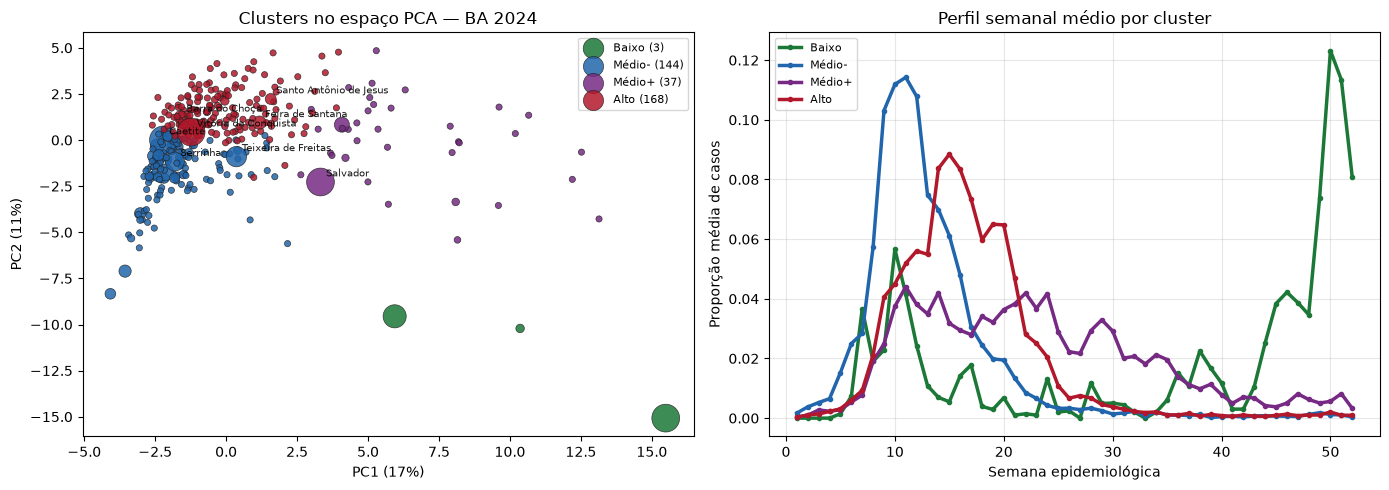

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = CLUSTER_COLORS[:K_CLUSTERS]

# PCA — tamanho do ponto ∝ total de casos
for c in range(K_CLUSTERS):
    sub = cluster_df[cluster_df["cluster"] == c]
    axes[0].scatter(
        sub["pc1"],
        sub["pc2"],
        s=np.clip(sub["total"] / sub["total"].max() * 400, 20, 400),
        alpha=0.85,
        c=colors[c],
        label=f"{CLUSTER_NOMES[c]} ({len(sub)})",
        edgecolors="#222",
        linewidths=0.5,
    )

for _, row in cluster_df.nlargest(8, "total").iterrows():
    axes[0].annotate(
        row["municipio"],
        (row["pc1"], row["pc2"]),
        fontsize=7,
        alpha=0.9,
        xytext=(4, 4),
        textcoords="offset points",
    )

axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
axes[0].set_title(f"Clusters no espaço PCA — BA {ANO_CLUSTER}")
axes[0].legend(fontsize=8, loc="best")

for c in range(K_CLUSTERS):
    mask = labels == c
    media = perfis.values[mask].mean(axis=0)
    axes[1].plot(semana_idx, media, marker="o", ms=3, lw=2.5, color=colors[c], label=CLUSTER_NOMES[c])

axes[1].set_xlabel("Semana epidemiológica")
axes[1].set_ylabel("Proporção média de casos")
axes[1].set_title("Perfil semanal médio por cluster")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
import copy

with GEO.open(encoding="utf-8") as f:
    geo_clusters_base = json.load(f)

geo_clusters = copy.deepcopy(geo_clusters_base)
cluster_lookup = cluster_df.set_index("codarea")["cluster"].astype(int).to_dict()
nome_lookup = cluster_df.set_index("codarea")["municipio"].to_dict()
colors = CLUSTER_COLORS[:K_CLUSTERS]

for feat in geo_clusters["features"]:
    ca = str(feat["properties"]["codarea"])
    feat["properties"]["cluster"] = cluster_lookup.get(ca, -1)
    feat["properties"]["municipio"] = nome_lookup.get(ca, ca)


def cluster_style(feat: dict) -> dict:
    c = feat["properties"]["cluster"]
    if c < 0:
        return {"fillColor": "#bdbdbd", "color": "#666", "weight": 0.8, "fillOpacity": 0.45}
    return {
        "fillColor": colors[c],
        "color": "#111",
        "weight": 1.2,
        "fillOpacity": 0.92,
    }


m_cluster = folium.Map(location=[-12.5, -41.7], zoom_start=6, tiles="OpenStreetMap")
folium.GeoJson(
    geo_clusters,
    style_function=cluster_style,
    highlight_function=lambda feat: {"weight": 2.5, "color": "#000", "fillOpacity": 1.0},
    tooltip=folium.GeoJsonTooltip(
        fields=["municipio", "cluster"],
        aliases=["Município", "Cluster"],
    ),
).add_to(m_cluster)

legend_html = (
    "<div style='position:fixed;bottom:30px;left:30px;z-index:9999;background:white;"
    "padding:12px;border:2px solid #333;font-size:13px;line-height:1.8'>"
    f"<b>Clusters — {ANO_CLUSTER}</b><br>"
    + "<br>".join(
        f"<span style='color:{colors[i]};font-size:20px;font-weight:bold'>&#9632;</span>"
        f" {CLUSTER_NOMES[i]}"
        for i in range(K_CLUSTERS)
    )
    + "<br><span style='color:#bdbdbd;font-size:20px'>&#9632;</span> sem cluster (&lt; min casos)"
    "</div>"
)
m_cluster.get_root().html.add_child(folium.Element(legend_html))
display(m_cluster)

## 7. Cluster **semana a semana** (ideia original)

Diferente da seção 6 (um cluster **fixo** por município no ano inteiro), aqui:

1. Escolhe **uma semana epidemiológica**
2. Agrupa municípios pelo **volume de casos naquela semana**
3. Repete para cada semana → vê **quem muda de cluster** ao longo do ano

Ao lado do mapa: gráfico de **separação** (jitter + silhouette) para ver se os clusters da semana fazem sentido.

In [50]:
if "CLUSTER_COLORS" not in dir():
    CLUSTER_COLORS = ["#1b7837", "#2166ac", "#762a83", "#b2182b"]
    CLUSTER_NOMES = ["Baixo", "Médio-", "Médio+", "Alto"]

if "ordenar_clusters_por_intensidade" not in dir():
    def ordenar_clusters_por_intensidade(labels: np.ndarray, valores: np.ndarray) -> tuple[np.ndarray, dict[int, int]]:
        media = pd.DataFrame({"lbl": labels, "v": valores}).groupby("lbl")["v"].mean().sort_values()
        old_to_new = {int(old): new for new, old in enumerate(media.index)}
        return np.array([old_to_new[int(l)] for l in labels]), old_to_new

ANO_DIN = ANO
K_SEM = 4
MIN_SEM = 30

path_din = ROOT / "data" / "processed" / UF / "raw" / f"DENG{UF.upper()}{str(ANO_DIN)[-2:]}.csv"
df_din = pd.read_csv(path_din, usecols=["ID_MUNICIP", "SEM_NOT"], low_memory=False)

mat = (
    df_din.groupby(["ID_MUNICIP", "SEM_NOT"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

ativos = mat.sum(axis=1) >= MIN_SEM
mat_at = mat.loc[ativos]

semana_cols = mat_at.columns.astype(int)
sem_num_to_col = {int(str(s)[-2:]): s for s in semana_cols}

assignments: dict[int, pd.Series] = {}
for num_sem, col in sem_num_to_col.items():
    casos = mat_at[col].values
    x = np.log1p(casos.reshape(-1, 1))
    lbl_raw = KMeans(n_clusters=K_SEM, random_state=42, n_init=10).fit_predict(x)
    lbl, _ = ordenar_clusters_por_intensidade(lbl_raw, casos)
    assignments[num_sem] = pd.Series(lbl, index=mat_at.index, name="cluster")

assign_df = pd.DataFrame(assignments)
assign_df.index.name = "ID_MUNICIP"

mudou = assign_df.diff(axis=1).ne(0).iloc[:, 1:]
pct_mudou_semana = mudou.mean(axis=0) * 100
transicoes = mudou.sum(axis=1).rename("trocas")

meta = assign_df.reset_index()
meta["codarea"] = meta["ID_MUNICIP"].map(id_to_codarea)
meta = meta.merge(ibge_nomes, on="codarea", how="left")
nome_map = meta.set_index("ID_MUNICIP")["municipio"].to_dict()

print(f"Ano {ANO_DIN} | {len(mat_at)} municípios | {len(assign_df.columns)} semanas | k={K_SEM}")
print(f"Média de municípios que mudam de cluster/semana: {pct_mudou_semana.mean():.1f}%")
transicoes.sort_values(ascending=False).head(8)

Ano 2024 | 352 municípios | 52 semanas | k=4
Média de municípios que mudam de cluster/semana: 30.3%


ID_MUNICIP
292270    33
293190    31
290135    29
290980    29
293060    28
290860    28
290520    27
291072    26
Name: trocas, dtype: int64

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

colors_sem = CLUSTER_COLORS[:K_SEM]
nomes_sem = CLUSTER_NOMES[:K_SEM] if "CLUSTER_NOMES" in dir() else [f"C{i}" for i in range(K_SEM)]

map_out_sem = widgets.Output()
plot_out_sem = widgets.Output()
info_sem = widgets.HTML()

slider_sem = widgets.IntSlider(
    value=int(min(assign_df.columns)),
    min=int(min(assign_df.columns)),
    max=int(max(assign_df.columns)),
    step=1,
    description="Semana",
    continuous_update=False,
    readout_format="d",
    layout=widgets.Layout(width="500px"),
)


def mapa_semana(num_sem: int) -> folium.Map:
    col_sem = sem_num_to_col[num_sem]
    lookup_sem = assign_df[num_sem].to_dict()

    with GEO.open(encoding="utf-8") as f:
        geo_sem = json.load(f)

    for feat in geo_sem["features"]:
        ca = str(feat["properties"]["codarea"])
        id6 = int(ca) // 10
        c = lookup_sem.get(id6, -1)
        feat["properties"]["cluster"] = int(c)
        feat["properties"]["nivel"] = nomes_sem[c] if c >= 0 else "—"
        feat["properties"]["municipio"] = nome_map.get(id6, ca)
        feat["properties"]["casos"] = int(mat_at.at[id6, col_sem]) if id6 in mat_at.index else 0

    def style(feat: dict) -> dict:
        c = feat["properties"]["cluster"]
        if c < 0:
            return {"fillColor": "#bdbdbd", "color": "#666", "weight": 0.8, "fillOpacity": 0.45}
        return {"fillColor": colors_sem[c], "color": "#111", "weight": 1.2, "fillOpacity": 0.92}

    m = folium.Map(location=[-12.5, -41.7], zoom_start=6, tiles="OpenStreetMap")
    folium.GeoJson(
        geo_sem,
        style_function=style,
        highlight_function=lambda feat: {"weight": 2.5, "color": "#000", "fillOpacity": 1.0},
        tooltip=folium.GeoJsonTooltip(
            fields=["municipio", "casos", "nivel"],
            aliases=["Município", "Casos na semana", "Intensidade"],
        ),
    ).add_to(m)
    return m


def plot_semana(num_sem: int) -> None:
    """Diagnóstico: clusters bem separados? (box/jitter + silhouette)"""
    col_sem = sem_num_to_col[num_sem]
    casos = mat_at[col_sem]
    clusters = assign_df[num_sem]
    x_feat = np.log1p(casos.values.reshape(-1, 1))
    sil = silhouette_score(x_feat, clusters.values)

    plot_df = pd.DataFrame({"casos": casos.values, "cluster": clusters.values})
    rng = np.random.default_rng(42)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

    for c in range(K_SEM):
        sub = plot_df.loc[plot_df["cluster"] == c, "casos"]
        axes[0].scatter(
            rng.normal(c, 0.07, len(sub)),
            sub,
            alpha=0.5,
            s=22,
            c=colors_sem[c],
            edgecolors="#222",
            linewidths=0.25,
            label=f"{nomes_sem[c]} (n={len(sub)})",
        )
    axes[0].set_xticks(range(K_SEM))
    axes[0].set_xticklabels(nomes_sem)
    axes[0].set_yscale("symlog", linthresh=1)
    axes[0].set_ylabel("Casos na semana")
    axes[0].set_title("Casos por cluster")
    axes[0].legend(fontsize=7, loc="upper right")
    axes[0].grid(axis="y", alpha=0.3)

    agg = plot_df.groupby("cluster")["casos"].agg(["count", "mean"])
    counts = agg["count"].reindex(range(K_SEM), fill_value=0)
    means = agg["mean"].reindex(range(K_SEM), fill_value=0)
    axes[1].bar(range(K_SEM), counts, color=colors_sem, edgecolor="#111", alpha=0.9)
    axes[1].set_xticks(range(K_SEM))
    axes[1].set_xticklabels(nomes_sem)
    axes[1].set_ylabel("Municípios")
    ax_r = axes[1].twinx()
    ax_r.plot(range(K_SEM), means, "D--k", ms=6, lw=1.5)
    ax_r.set_ylabel("Média casos")
    axes[1].set_title("Tamanho × intensidade")

    qualidade = "boa" if sil >= 0.25 else "média" if sil >= 0.1 else "fraca"
    fig.suptitle(
        f"Semana {num_sem:02d} — silhouette {sil:.2f} ({qualidade})",
        fontsize=10,
        y=1.02,
    )
    plt.tight_layout()
    return sil


def render_semana(num_sem: int) -> None:
    casos_sem = int(mat_at[sem_num_to_col[num_sem]].sum())
    pct = pct_mudou_semana.get(num_sem, np.nan)
    pct_txt = f"{pct:.1f}%" if num_sem in pct_mudou_semana.index else "—"

    with plot_out_sem:
        clear_output(wait=True)
        sil = plot_semana(num_sem)
        plt.show()

    info_sem.value = (
        f"<b>Semana {num_sem:02d}/{ANO_DIN}</b> — {casos_sem:,} casos na BA "
        f"| {pct_txt} mudaram de cluster "
        f"| silhouette <b>{sil:.2f}</b> (1=separado, 0=misturado)".replace(",", ".")
    )
    with map_out_sem:
        clear_output(wait=True)
        display(mapa_semana(num_sem))


slider_sem.observe(lambda ch: render_semana(ch["new"]) if ch["name"] == "value" else None, names="value")
render_semana(slider_sem.value)

painel = widgets.HBox(
    [
        widgets.VBox([widgets.HTML("<b>Mapa</b>"), map_out_sem], layout=widgets.Layout(width="58%")),
        widgets.VBox([widgets.HTML("<b>Separação dos clusters</b>"), plot_out_sem], layout=widgets.Layout(width="42%")),
    ],
    layout=widgets.Layout(width="100%"),
)
display(widgets.VBox([slider_sem, info_sem, painel]))

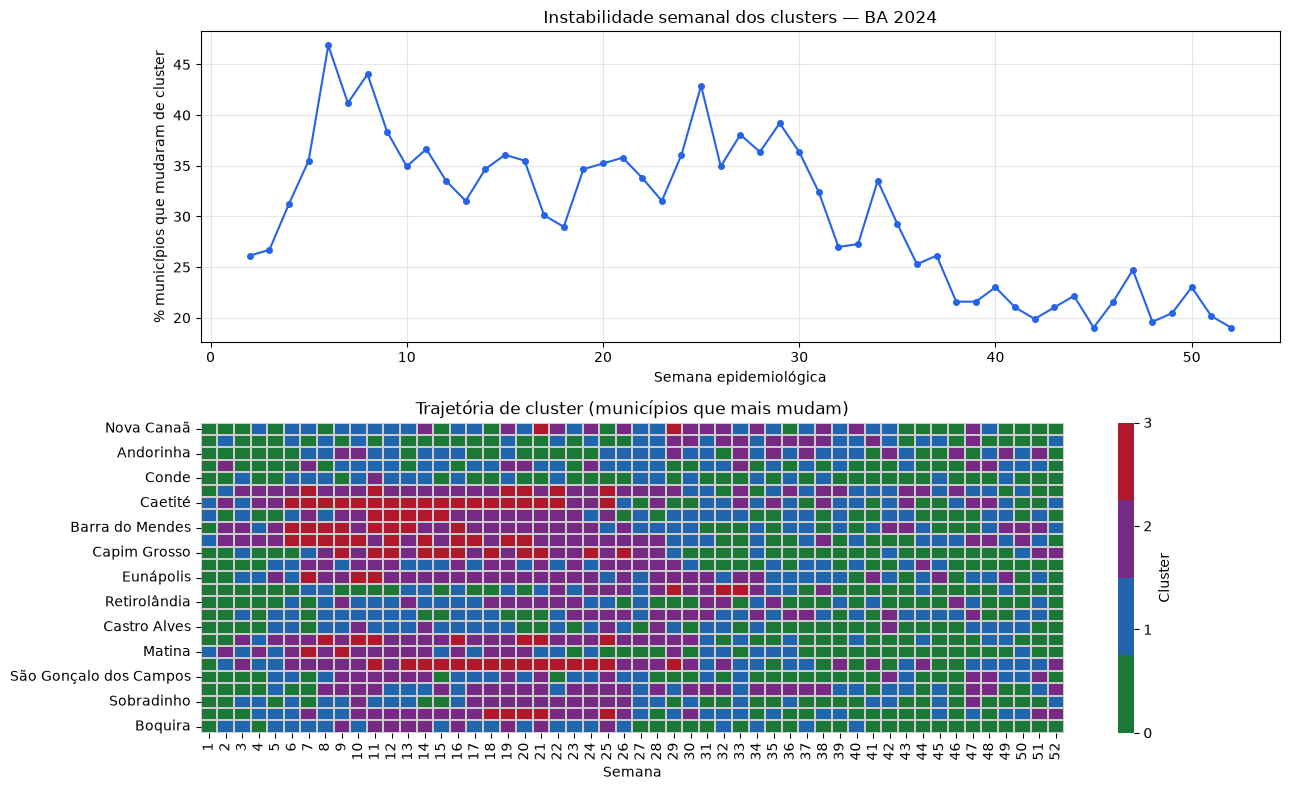

In [52]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(pct_mudou_semana.index, pct_mudou_semana.values, marker="o", ms=4, color="#2563eb")
axes[0].set_xlabel("Semana epidemiológica")
axes[0].set_ylabel("% municípios que mudaram de cluster")
axes[0].set_title(f"Instabilidade semanal dos clusters — BA {ANO_DIN}")
axes[0].grid(alpha=0.3)

top_inst = transicoes.nlargest(25).index
hm = assign_df.loc[top_inst].copy()
hm.index = [nome_map.get(i, i) for i in hm.index]

cmap_hm = ListedColormap(CLUSTER_COLORS[:K_SEM] if "CLUSTER_COLORS" in dir() else colors_sem)

sns.heatmap(
    hm,
    ax=axes[1],
    cmap=cmap_hm,
    vmin=0,
    vmax=K_SEM - 1,
    cbar_kws={"label": "Cluster", "ticks": range(K_SEM)},
    linewidths=0.2,
    linecolor="#ccc",
)
axes[1].set_title("Trajetória de cluster (municípios que mais mudam)")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()